In [105]:
import numpy as np
import xarray as xr
from weatherbenchX.data_loaders import xarray_loaders
from weatherbenchX import aggregation
from weatherbenchX import weighting
from weatherbenchX import binning
from weatherbenchX import time_chunks
from weatherbenchX.metrics import probabilistic
from tqdm import tqdm

import swissclim_evaluations.data as data
from swissclim_evaluations.metrics.wbx import CRPSEnsemble, SpreadSkillRatio
from swissclim_evaluations.metrics.probabilistic import probability_integral_transform

In [76]:
EVAL_DATASET = "esmf_ensemble"

fct = getattr(data, EVAL_DATASET)(variables=data.VARIABLES_2D)
obs = data.era5(variables=data.VARIABLES_2D)

lsm = data.land_sea_mask().compute()

In [77]:
obs, fct = xr.align(obs, fct, join="inner")
obs = obs.sel(time=slice(None, fct["valid_time"].max().values))

In [ ]:
init_times = fct["init_time"].values
lead_times = np.array([6], dtype='timedelta64[h]').astype('timedelta64[ns]')

target_dataloader = xarray_loaders.TargetsFromXarray(
    ds=obs,
    variables=data.VARIABLES_2D,
    # rename_dimensions=None,
    compute=False,
)

pred_dataloader = xarray_loaders.PredictionsFromXarray(
    ds=fct,
    variables=data.VARIABLES_2D,
    rename_dimensions=None,
    compute=False,
)

# pred_dataloader.load_chunk(init_times, lead_times)

<xarray.Dataset> Size: 98GB
Dimensions:                  (init_time: 739, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * init_time                (init_time) datetime64[ns] 6kB 2021-01-01T06:00:...
    valid_time               (init_time, lead_time) datetime64[ns] 6kB 2021-0...
Data variables:
    10m_u_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    10m_v_component_of_wind  (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    2m_temperature           (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>
    mean_sea_level_pressure  (init_time, lead_time, ensemble, latitude, longitude) float32 25GB dask.array<chunksize=(1, 1, 8, 720, 1440), meta=np.ndarray>

In [91]:
metrics = {
  "CRPS": CRPSEnsemble(ensemble_dim="ensemble"),
#   "CRPS": probabilistic.CRPSEnsemble(ensemble_dim="ensemble"),
  "SSR": SpreadSkillRatio(ensemble_dim="ensemble"),
}


# define spatial aggregation
weigh_by = [weighting.GridAreaWeighting()]

regions = {
    'global': ((-90, 90), (0, 360)),
    'tropics': ((-20, 20), (0, 360)),
    'northern-hemisphere': ((20, 90), (0, 360)),
    'southern-hemisphere': ((-90, -20), (0, 360)),
    'europe': ((35, 75), (-12.5, 42.5)),
    'north-america': ((25, 60), (360 - 120, 360 - 75)),
    'north-atlantic': ((25, 65), (360 - 70, 360 - 10)),
    'north-pacific': ((25, 60), (145, 360 - 130)),
    'east-asia': ((25, 60), (102.5, 150)),
    'ausnz': ((-45, -12.5), (120, 175)),
    'arctic': ((60, 90), (0, 360)),
    'antarctic': ((-90, -60), (0, 360)),
}

bin_by = [binning.Regions(regions=regions, land_sea_mask=lsm)]
spatial_aggregator = aggregation.Aggregator(
    reduce_dims=["latitude", "longitude"],
    bin_by=bin_by,
    weigh_by=weigh_by,
)


# define temporal aggregation
bin_by = [binning.ByTimeUnit("season", "init_time")]
temporal_aggregator = aggregation.Aggregator(
    reduce_dims=["init_time"],
    # bin_by=bin_by,
)

In [106]:
init_times = fct["init_time"].values
lead_times = np.array([6], dtype='timedelta64[h]').astype('timedelta64[ns]')

times = time_chunks.TimeChunks(
  init_times,
  lead_times,
  init_time_chunk_size=20,
  lead_time_chunk_size=1
)

spatial_results = None
temporal_results = []
pbar_times = tqdm(times, desc="Computing metrics")
for i, chunk_times in enumerate(pbar_times):

  pred_chunk: xr.Dataset = pred_dataloader.load_chunk(*chunk_times)
  target_chunk: xr.Dataset = target_dataloader.load_chunk(*chunk_times)

  pred_chunk = pred_chunk.chunk({"init_time": 1}).persist(scheduler="threads", num_workers=10)
  target_chunk = target_chunk.chunk({"init_time": 1}).persist(scheduler="threads", num_workers=10)

  temporal_results += [
    aggregation.compute_metric_values_for_single_chunk(metrics, spatial_aggregator, pred_chunk, target_chunk)
  ]

  if spatial_results is None:
    spatial_results = aggregation.compute_metric_values_for_single_chunk(metrics, temporal_aggregator, pred_chunk, target_chunk)
  else:
    spatial_results += aggregation.compute_metric_values_for_single_chunk(metrics, temporal_aggregator, pred_chunk, target_chunk)

spatial_results /= i + 1
temporal_results = xr.merge(temporal_results)
  

Computing metrics: 100%|██████████| 37/37 [10:56<00:00, 17.74s/it]


In [107]:
fn = "/capstor/store/cscs/swissai/a01/ESFM_Results/aurora_tail_probabilistic_metrics.nc"
temporal_results.to_netcdf(fn)

fn = "/capstor/store/cscs/swissai/a01/ESFM_Results/aurora_tail_probabilistic_metrics_spatial.nc"
spatial_results.to_netcdf(fn)

In [115]:
temporal_results.mean("init_time").to_dataframe()

CRPS.10m_u_component_of_wind  ...  SSR.10m_v_component_of_wind
lead_time       region                                                  ...                             
0 days 06:00:00 global                                        0.278134  ...                     1.037268
                tropics                                       0.261148  ...                     0.968129
                northern-hemisphere                           0.299250  ...                     1.000600
                southern-hemisphere                           0.274742  ...                     1.160469
                europe                                        0.329764  ...                     0.971985
                north-america                                 0.273513  ...                     0.983875
                north-atlantic                                0.353371  ...                     1.057457
                north-pacific                                 0.383619  ...                     1.028475
                east-asia                                     0.317433  ...                     0.971545
                ausnz                                         0.348229  ...                     1.024686
                arctic                                        0.258365  ...                     0.969089
                antarctic                                     0.259176  ...                     1.115719
                global_land                                   0.268876  ...                     1.011436
                tropics_land                                  0.267343  ...                     0.992238
                northern-hemisphere_land                      0.261564  ...                     1.004035
                southern-hemisphere_land                      0.292330  ...                     1.060680
                europe_land                                   0.292374  ...                     0.965793
                north-america_land                            0.267654  ...                     0.983796
                north-atlantic_land                           0.300762  ...                     1.018680
                north-pacific_land                            0.360156  ...                     1.059333
                east-asia_land                                0.268710  ...                     1.001971
                ausnz_land                                    0.366004  ...                     1.005141
                arctic_land                                   0.233854  ...                     0.972055
                antarctic_land                                0.238363  ...                     1.060911

[24 rows x 8 columns]

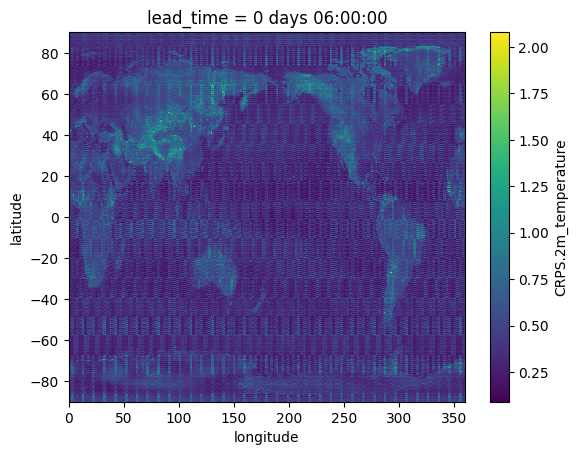

In [113]:
spatial_results["CRPS.2m_temperature"][0].plot()

In [104]:
# import matplotlib.pyplot as plt


# fig, ax = plt.subplots(figsize=(8,7))
# land = temporal_results.mean(["init_time", "lead_time"])["CRPS.10m_u_component_of_wind"].sel(region=[r.item() for r in temporal_results["region"] if "_land" in r.item()])
# full = temporal_results.mean(["init_time", "lead_time"])["CRPS.10m_u_component_of_wind"].sel(region=[r.item() for r in temporal_results["region"] if "_land" not in r.item()])
# # temporal_results.mean(["init_time"])
# land = land.assign_coords(region=[r.item() for r in full["region"]])

# # orientation of xlabels must be vertical
# full[1:].plot(ax=ax, label="all", color="black")
# land[1:].plot(ax=ax, label="land", color="brown")
# ax.hlines(full[0].values, 0, len(full["region"][1:])-1, ls="--", ec="k", lw=1, label="all_global")
# ax.hlines(land[0].values, 0, len(land["region"][1:])-1, ls="--", ec="brown", lw=1, label="land_global")
# plt.xticks(rotation=90)
# # temporal_results
# plt.legend()
# # [r.item() for r in temporal_results["region"]]
